In [39]:
# Week_3_Assignment1

# TASKS

# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [40]:
# PART A : Dataset Understanding

# Q1. (i) Load the dataset and display first 10 records.

df = pd.read_csv("agriculture_yield_dataset.csv")

df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [41]:
# Q1. (ii) Determine number of rows and columns.

print("Shape:", df.shape)

# Ans:
# Rows = 1500
# Columns = 8

Shape: (1500, 8)


In [42]:
# Q1. (iii) Display all column names.

print(df.columns)

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


In [43]:
# Q2. (i) Check datatype of each column.

print(df.dtypes)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object


In [44]:
# Q2. (ii) Check missing values.

print(df.isnull().sum())


rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [45]:
# Q3. Generate descriptive statistics.

df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [46]:
# Highest mean value

print(df.describe().loc['mean'])

rainfall_mm              754.054667
temperature_c             27.749467
fertilizer_kg            148.744067
irrigation_hours           5.403267
soil_ph                    6.759133
yield_ton_per_hectare      5.028793
Name: mean, dtype: float64


In [47]:
# Highest standard deviation

print(df.describe().loc['std'])

rainfall_mm              255.097216
temperature_c              5.758101
fertilizer_kg             56.990279
irrigation_hours           2.584329
soil_ph                    0.719742
yield_ton_per_hectare      0.968282
Name: std, dtype: float64


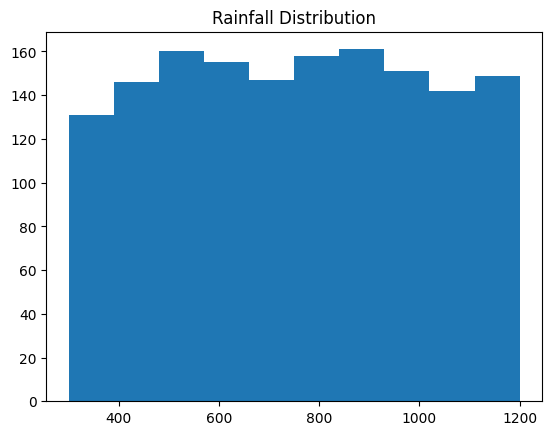

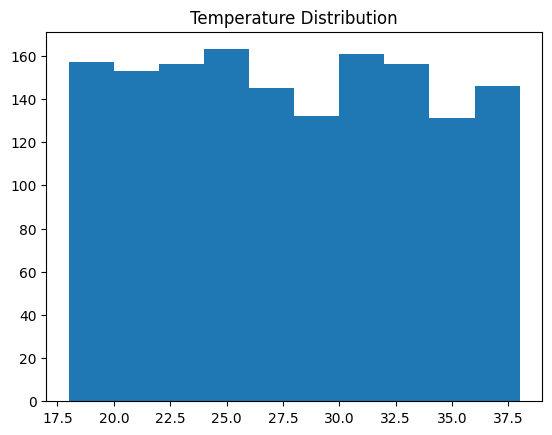

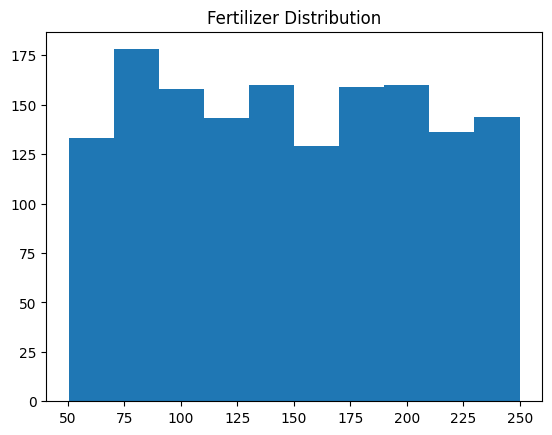

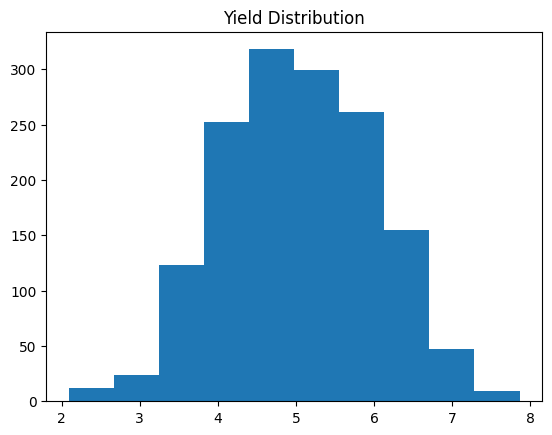

In [48]:
#Part B: Exploratory Data Analysis

# Q4.

## Histogram of Rainfall

plt.hist(df['rainfall_mm'])
plt.title("Rainfall Distribution")
plt.show()

# Observations:
# 1. Rainfall ranges approximately 300–1200 mm.
# 2. Distribution is fairly uniform.
# 3. No major outliers.

## Histogram of Temperature

plt.hist(df['temperature_c'])
plt.title("Temperature Distribution")
plt.show()

# Observations:
# 1. Most temperatures lie between 20°C and 35°C.
# 2. Distribution is roughly symmetric.
# 3. No strong skewness observed.

## Histogram of Fertilizer

plt.hist(df['fertilizer_kg'])
plt.title("Fertilizer Distribution")
plt.show()

# Observations:
# 1. Values are evenly distributed.
# 2. No extreme outliers.
# 3. Spread appears uniform.

## Histogram of Yield

plt.hist(df['yield_ton_per_hectare'])
plt.title("Yield Distribution")
plt.show()

# Observations:
# 1. Yield is centered around 5 tons/hectare.
# 2. Distribution is approximately normal.
# 3. Very few outliers.

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


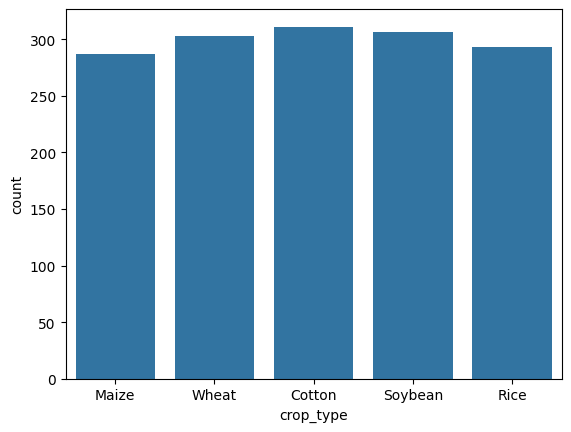

In [49]:
# Q5. Crop Type Analysis

print(df['crop_type'].value_counts())

sns.countplot(x='crop_type', data=df)
plt.show()

# Cotton appears most frequently.

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


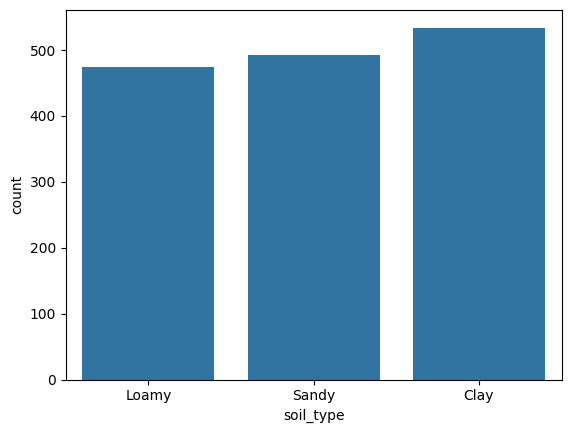

In [50]:
# Q6. Soil Type Analysis

print(df['soil_type'].value_counts())

sns.countplot(x='soil_type', data=df)
plt.show()

# Clay soil is most common.

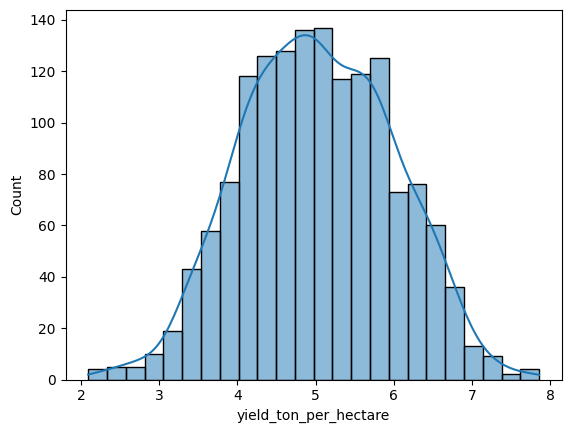

In [51]:
# Q7. Yield Distribution

sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.show()

# Distribution is approximately normal.
# No major outliers observed.

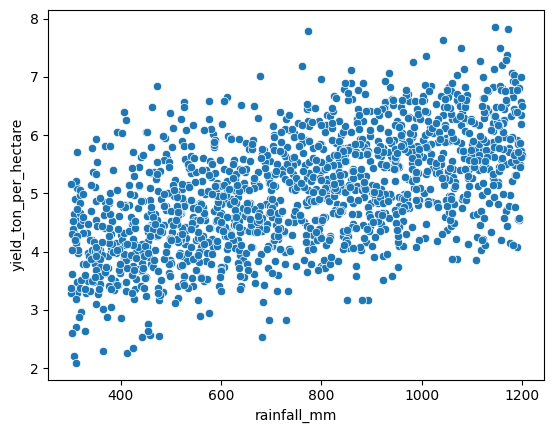

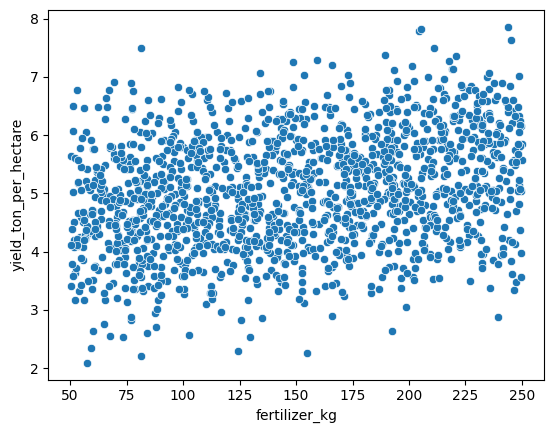

In [52]:
# Q8. Scatter Plot Analysis

sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.show()

sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.show()

# Rainfall appears to have stronger relationship with yield.

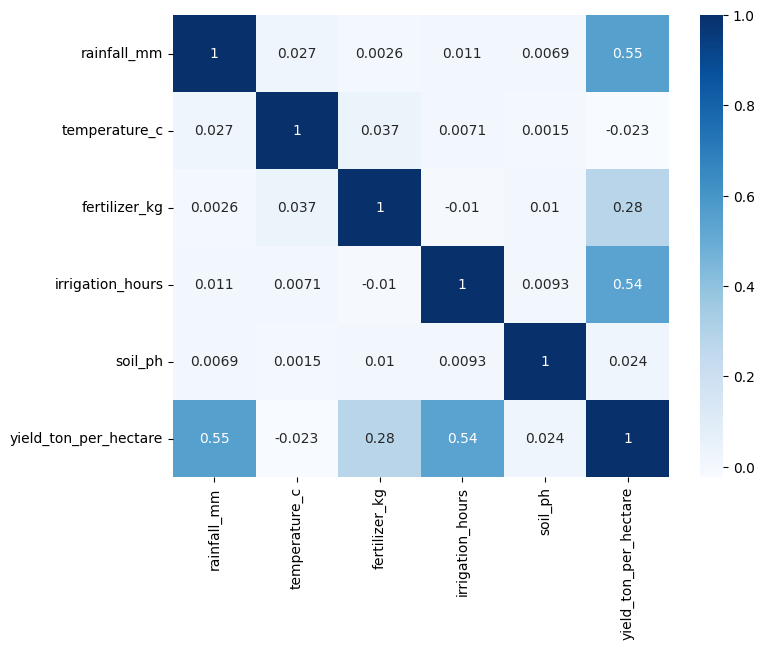

In [53]:
# Q9. Correlation Analysis

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

In [54]:
# Top correlations with yield

print(
corr['yield_ton_per_hectare']
.sort_values(ascending=False)
)

# 1. rainfall_mm
# 2. irrigation_hours
# 3. fertilizer_kg

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [55]:
# Q10. Average yield by crop

print(
df.groupby('crop_type')
['yield_ton_per_hectare']
.mean()
)

# Rice has highest average yield.

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [56]:
# Average yield by soil

print(
df.groupby('soil_type')
['yield_ton_per_hectare']
.mean()
)

# Loamy soil has highest average yield.


soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [57]:
#Part C: Data Preparation

# Q11. Identify categorical columns

print(df.select_dtypes(include='object').columns)


Index(['crop_type', 'soil_type'], dtype='object')


In [58]:
# One-Hot Encoding

df_encoded = pd.get_dummies(df)

df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


In [59]:
# Q12. Feature Selection

X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

# Target Variable:  yield_ton_per_hectare

In [60]:
#Part D: Linear Regression

# Q13. Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 13)
X_test : (300, 13)
y_train: (1200,)
y_test : (300,)


In [61]:
# Q14. Train Linear Regression Model

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [62]:
# Model Intercept

print("Intercept:", lr.intercept_)

Intercept: 1.9111026182800726


In [63]:
# Model Coefficients

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

# Feature with highest positive coefficient: crop_type_Rice

,Feature,Coefficient
7,crop_type_Rice,0.477369
11,soil_type_Loamy,0.365627
3,irrigation_hours,0.198327
8,crop_type_Soybean,0.095096
10,soil_type_Clay,0.062653
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
9,crop_type_Wheat,-0.038149
